# Figure 4

Computational panels D–G.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
from pathlib import Path

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)

# Override this environment variable when the shared data directory is mounted elsewhere.
DATA_ROOT = Path(
    os.environ.get("BIOAGENTS_DATA_ROOT", "/gpfs/group/jin/asun/bioagents/data")
)
DEG_PATH = DATA_ROOT / "wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet"
REPORTS_PATH = DATA_ROOT / "perturbai_reports" / "reports" / "html"


## Figure 4D — Relational-finding priority-score distribution


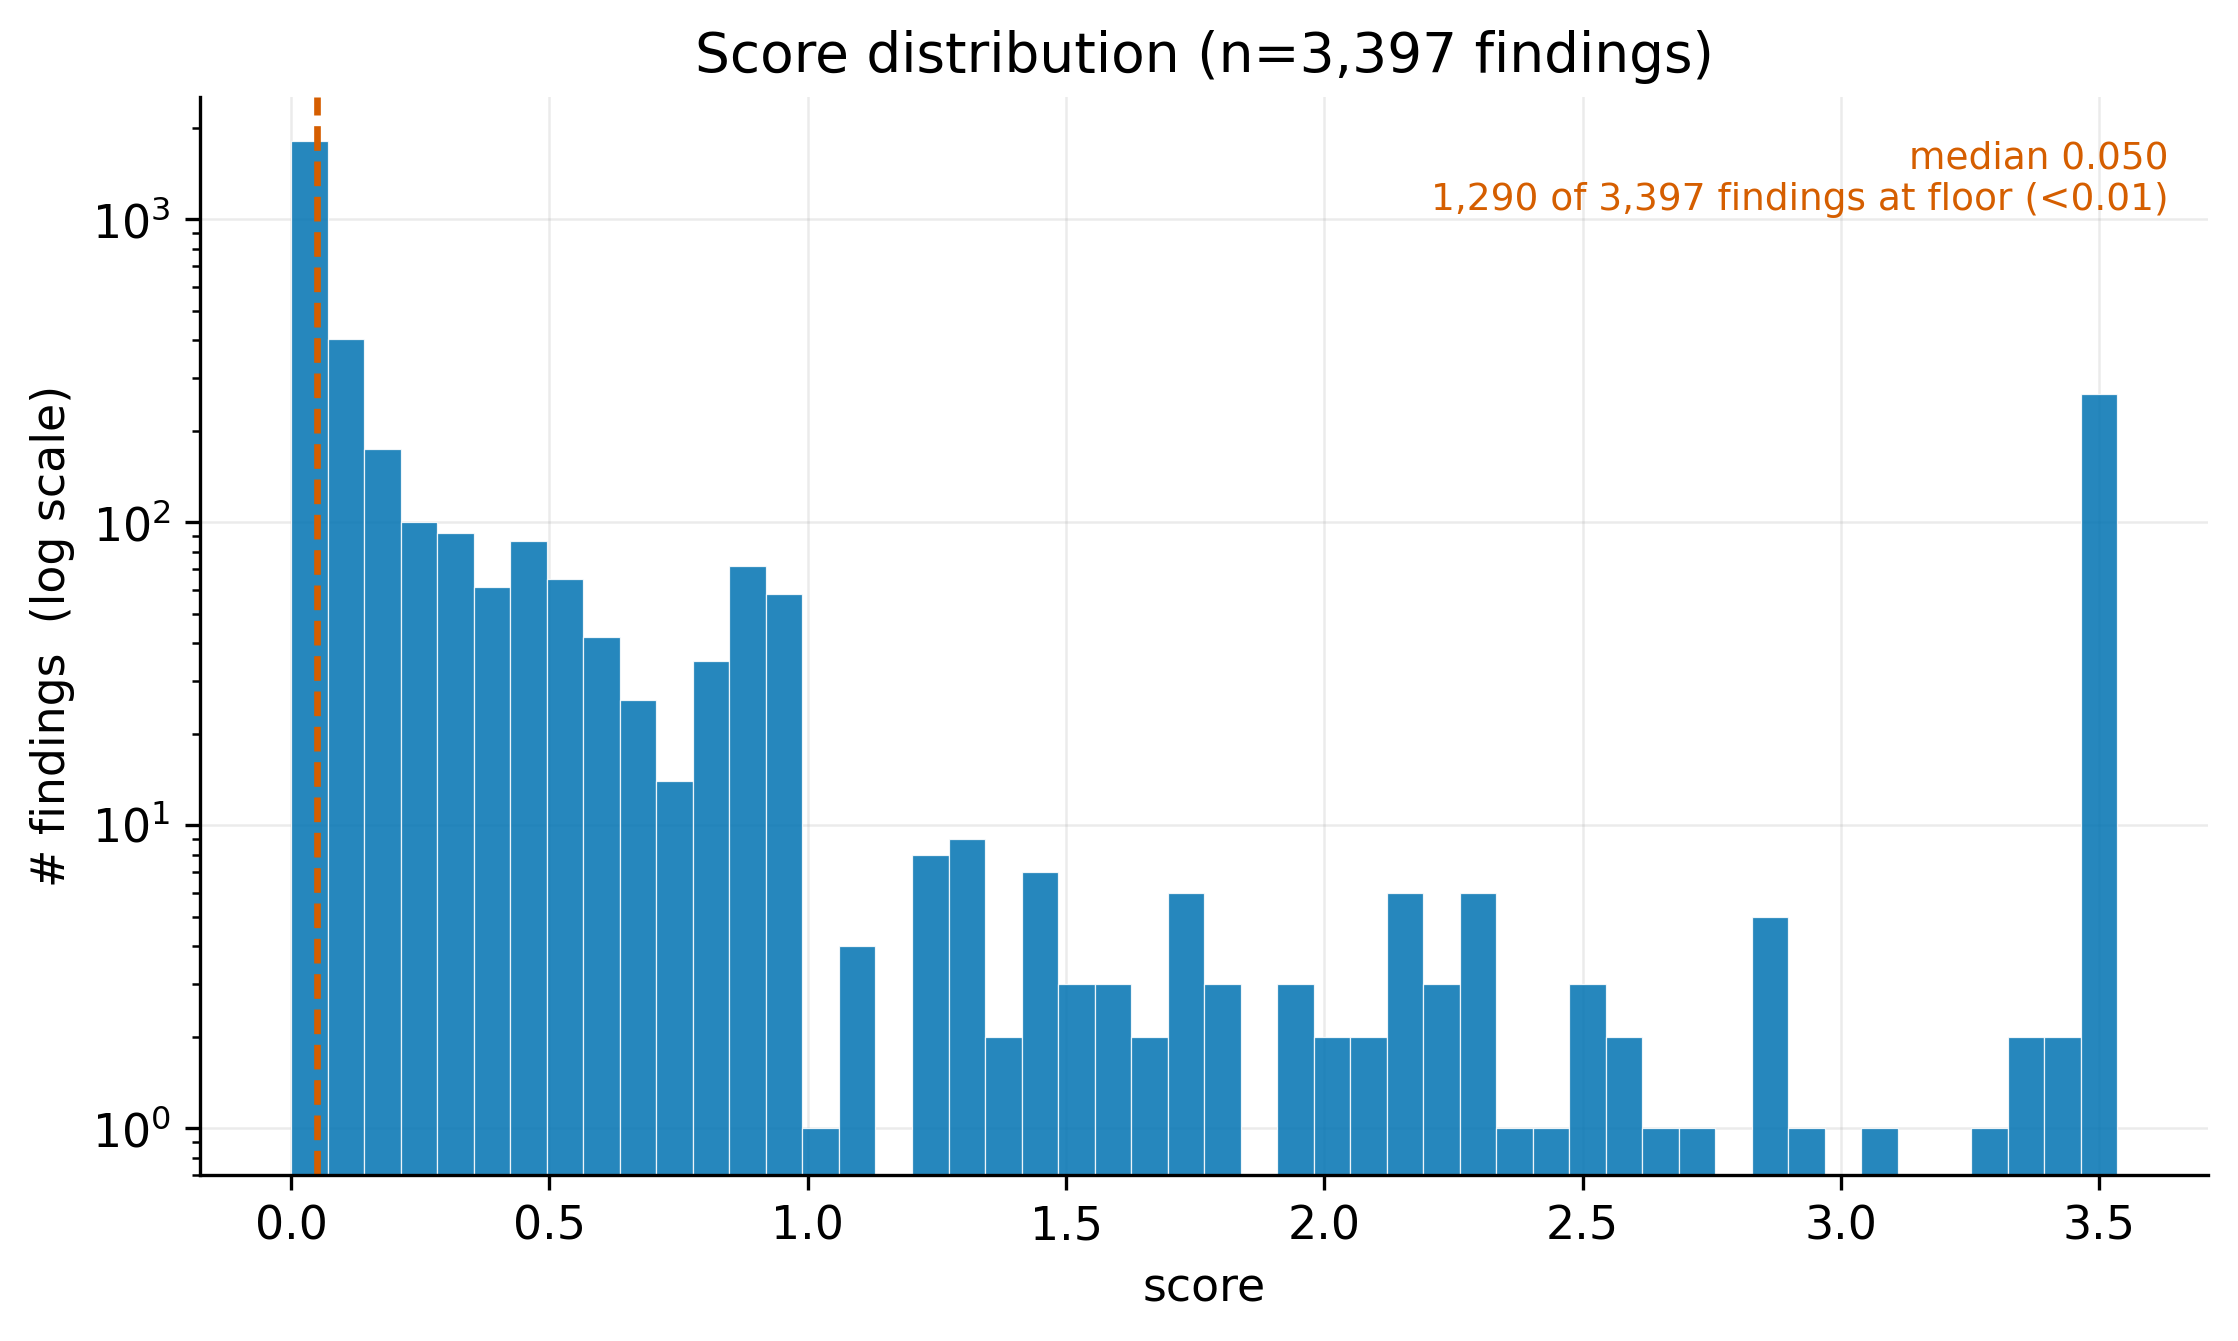

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

relational_path = ROOT / "src/manuscript_figures/fig4/d_f/inputs/analysis_table.csv"
relational = pd.read_csv(relational_path)
assert len(relational) == 3_397
scores = relational["evidence"].to_numpy(float)

# Okabe-Ito colorblind-safe colors and plotting defaults.
OI = {"blue": "#0072B2", "orange": "#E69F00", "vermillion": "#D55E00",
      "grey": "#999999"}
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

fig, ax = plt.subplots(figsize=(7.6, 4.6))
bins = np.linspace(0, scores.max(), 51)
counts, edges = np.histogram(scores, bins=bins)
# A positive baseline keeps log-scale bars finite in both raster and SVG output.
b0 = 0.7
ax.bar(edges[:-1], np.clip(counts - b0, 0, None), width=np.diff(edges),
       align="edge", bottom=b0, color=OI["blue"], alpha=0.85,
       edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_ylim(b0, counts.max() * 1.4)
n_floor = int((scores < 0.01).sum())
ax.axvline(np.median(scores), color=OI["vermillion"], lw=1.6, ls="--")
ax.text(0.98, 0.96,
        f"median {np.median(scores):.3f}\n{n_floor:,} of {len(scores):,} "
        "findings at floor (<0.01)",
        transform=ax.transAxes, va="top", ha="right", fontsize=9,
        color=OI["vermillion"])
ax.set(xlabel="score", ylabel="# findings  (log scale)",
       title=f"Score distribution (n={len(scores):,} findings)")
fig.tight_layout()
plt.show()


## Figure 4E — Priority score across perturbation DEG burden


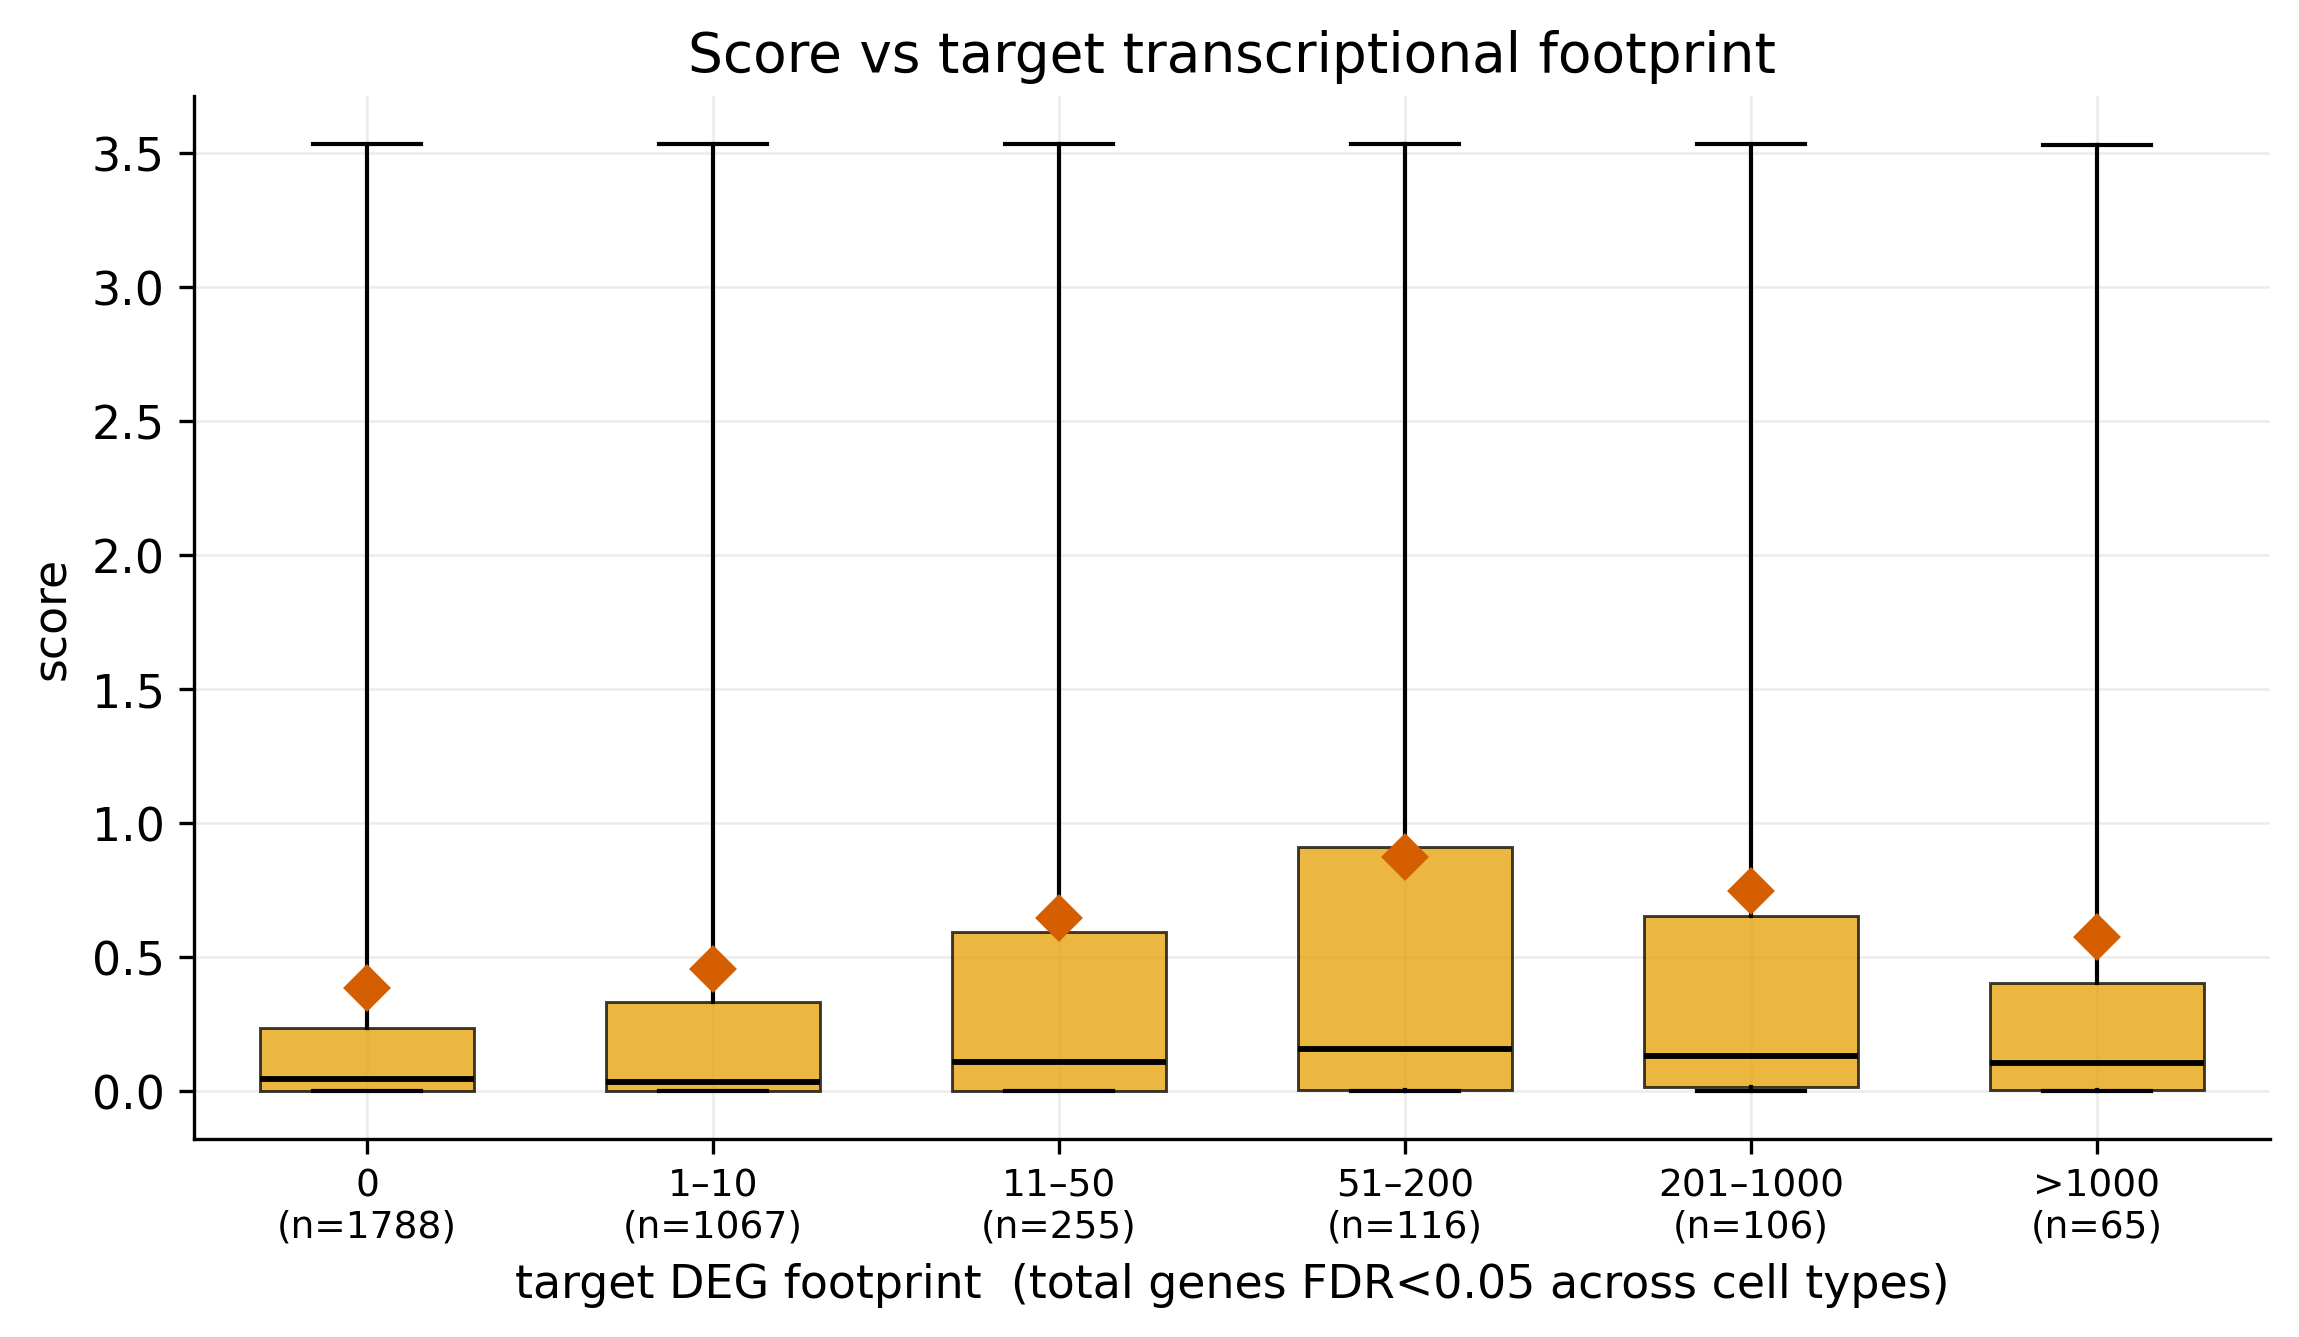

In [3]:
def _boxplot(ax, groups, colors, vert=False):
    bp = ax.boxplot(groups, vert=vert, patch_artist=True, widths=0.62,
                    whis=(0, 100), showfliers=False,
                    medianprops={"color": "black", "lw": 1.4})
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor("black")
        patch.set_linewidth(0.7)
    return bp

edges = [-0.5, 0.5, 10, 50, 200, 1000, np.inf]
labels = ["0", "1–10", "11–50", "51–200", "201–1000", ">1000"]
groups = []
deg_burden = relational["total_degs_padj_0.05"].to_numpy(float)
for lo, hi in zip(edges[:-1], edges[1:]):
    groups.append(scores[(deg_burden > lo) & (deg_burden <= hi)])

counts = [len(group) for group in groups]
means = [np.mean(group) for group in groups]
assert counts == [1788, 1067, 255, 116, 106, 65]

fig, ax = plt.subplots(figsize=(7.8, 4.6))
_boxplot(ax, groups, [OI["orange"]] * len(groups), vert=True)
ax.plot(range(1, len(labels) + 1), means, "D", color=OI["vermillion"],
        ms=7, zorder=5)
ax.set_xticks(range(1, len(labels) + 1),
              [f"{label}\n(n={count})" for label, count in zip(labels, counts)],
              fontsize=9)
ax.set(xlabel="target DEG footprint  (total genes FDR<0.05 across cell types)",
       ylabel="score",
       title="Score vs target transcriptional footprint")
fig.tight_layout()
plt.show()


## Figure 4F — Priority score across top GO Biological Process pathways


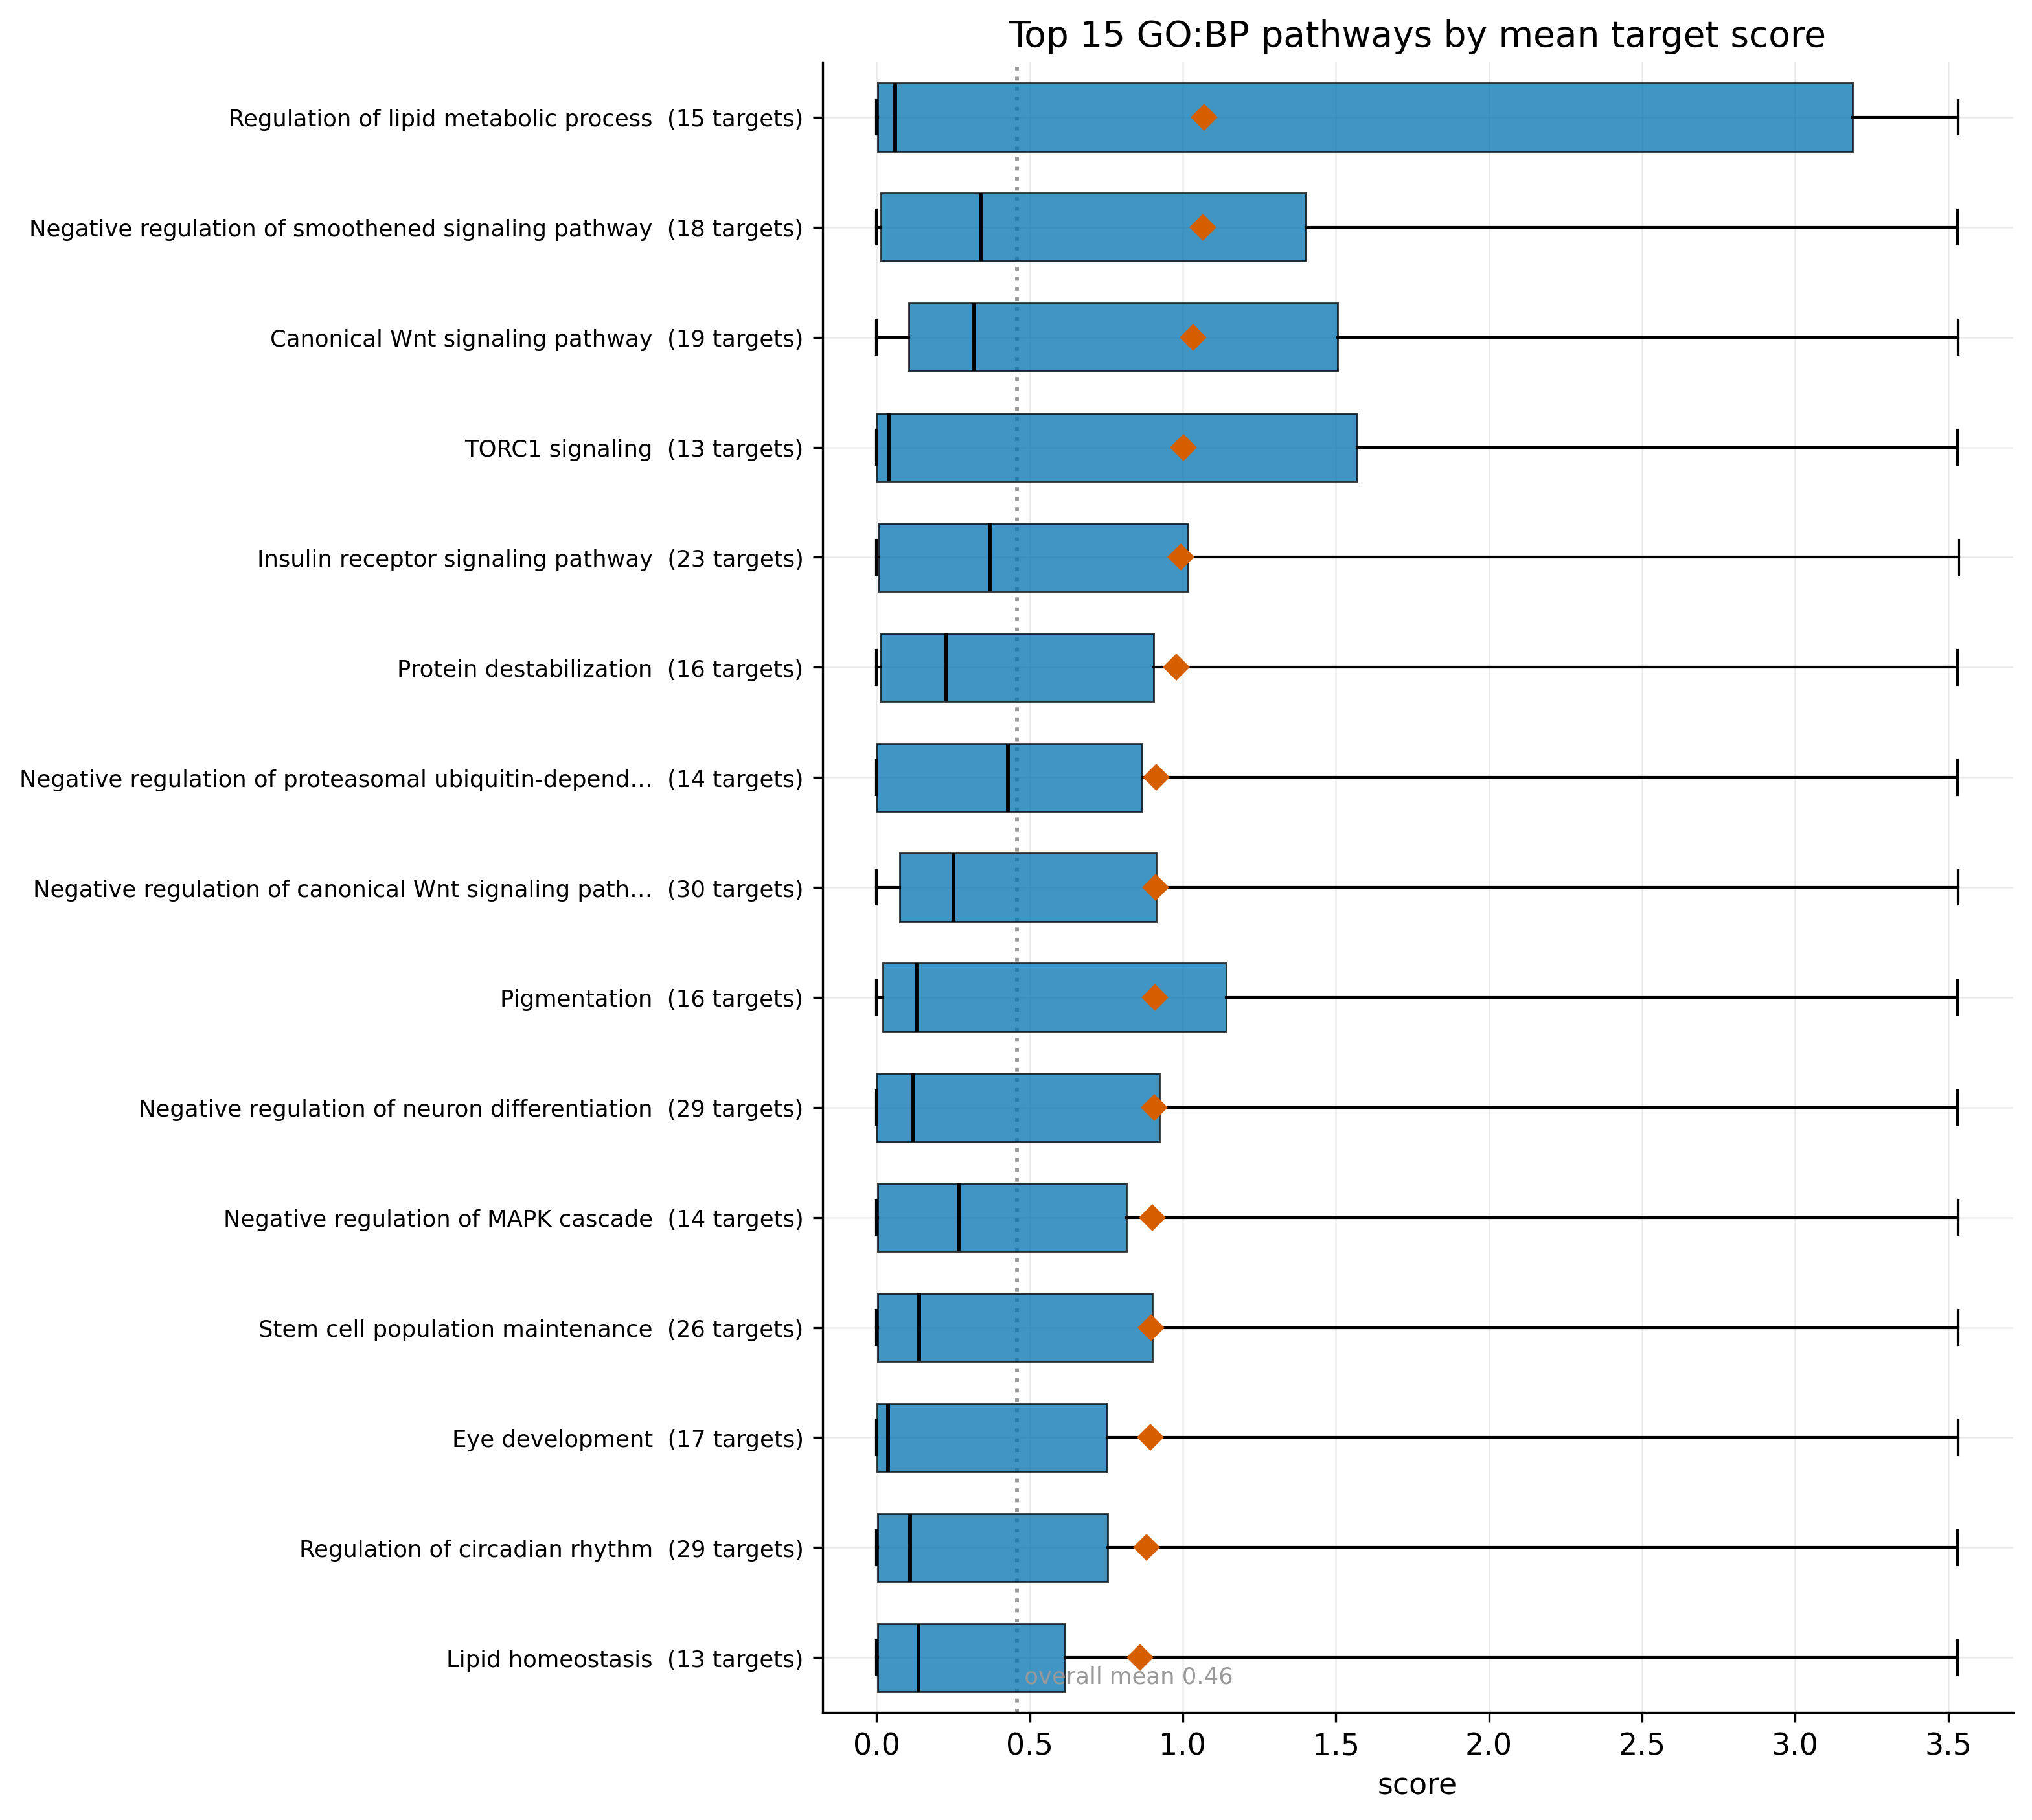

In [4]:
from collections import defaultdict

membership_path = ROOT / "src/manuscript_figures/fig4/d_f/inputs/gene_membership.parquet"
membership = pd.read_parquet(membership_path, columns=["gene", "resource", "set_name"])

scores_by_gene = defaultdict(list)
for gene, score in relational[["gene", "evidence"]].itertuples(index=False):
    scores_by_gene[gene].append(float(score))

# Rank GO:BP sets by mean score across findings whose perturbed target belongs
# to the set. Membership is many-to-many, so this is a ranking, not a partition.
records = []
go_bp = membership[membership["resource"] == "GO:BP"]
for pathway, members in go_bp.groupby("set_name"):
    genes = set(members["gene"]) & set(scores_by_gene)
    if len(genes) < 10:
        continue
    pathway_scores = [score for gene in genes for score in scores_by_gene[gene]]
    if len(pathway_scores) < 25:
        continue
    records.append((np.mean(pathway_scores), len(genes), pathway_scores, str(pathway).strip()))

top = sorted(records, key=lambda row: row[0], reverse=True)[:15][::-1]
groups = [row[2] for row in top]

def _short_pathway(name, width=52):
    name = name[0:1].upper() + name[1:]
    return name if len(name) <= width else name[:width - 1] + "…"

labels = [f"{_short_pathway(row[3])}  ({row[1]} targets)" for row in top]
overall_mean = float(np.mean(scores))

fig, ax = plt.subplots(figsize=(10.6, 9.5))
_boxplot(ax, groups, [OI["blue"]] * len(groups), vert=False)
ax.plot([np.mean(group) for group in groups], range(1, len(groups) + 1), "D",
        color=OI["vermillion"], ms=6, zorder=5)
ax.set_yticks(range(1, len(groups) + 1), labels, fontsize=8.5)
ax.axvline(overall_mean, color=OI["grey"], ls=":", lw=1.4, zorder=1)
ax.text(overall_mean, 0.015, f" overall mean {overall_mean:.2f}",
        color=OI["grey"], fontsize=8.5, ha="left", va="bottom",
        transform=ax.get_xaxis_transform())
ax.set(xlabel="score",
       title="Top 15 GO:BP pathways by mean target score")
fig.tight_layout()
plt.show()


## Figure 4G — Setdb1/Ehmt1 protocadherin and HUSH-related responses

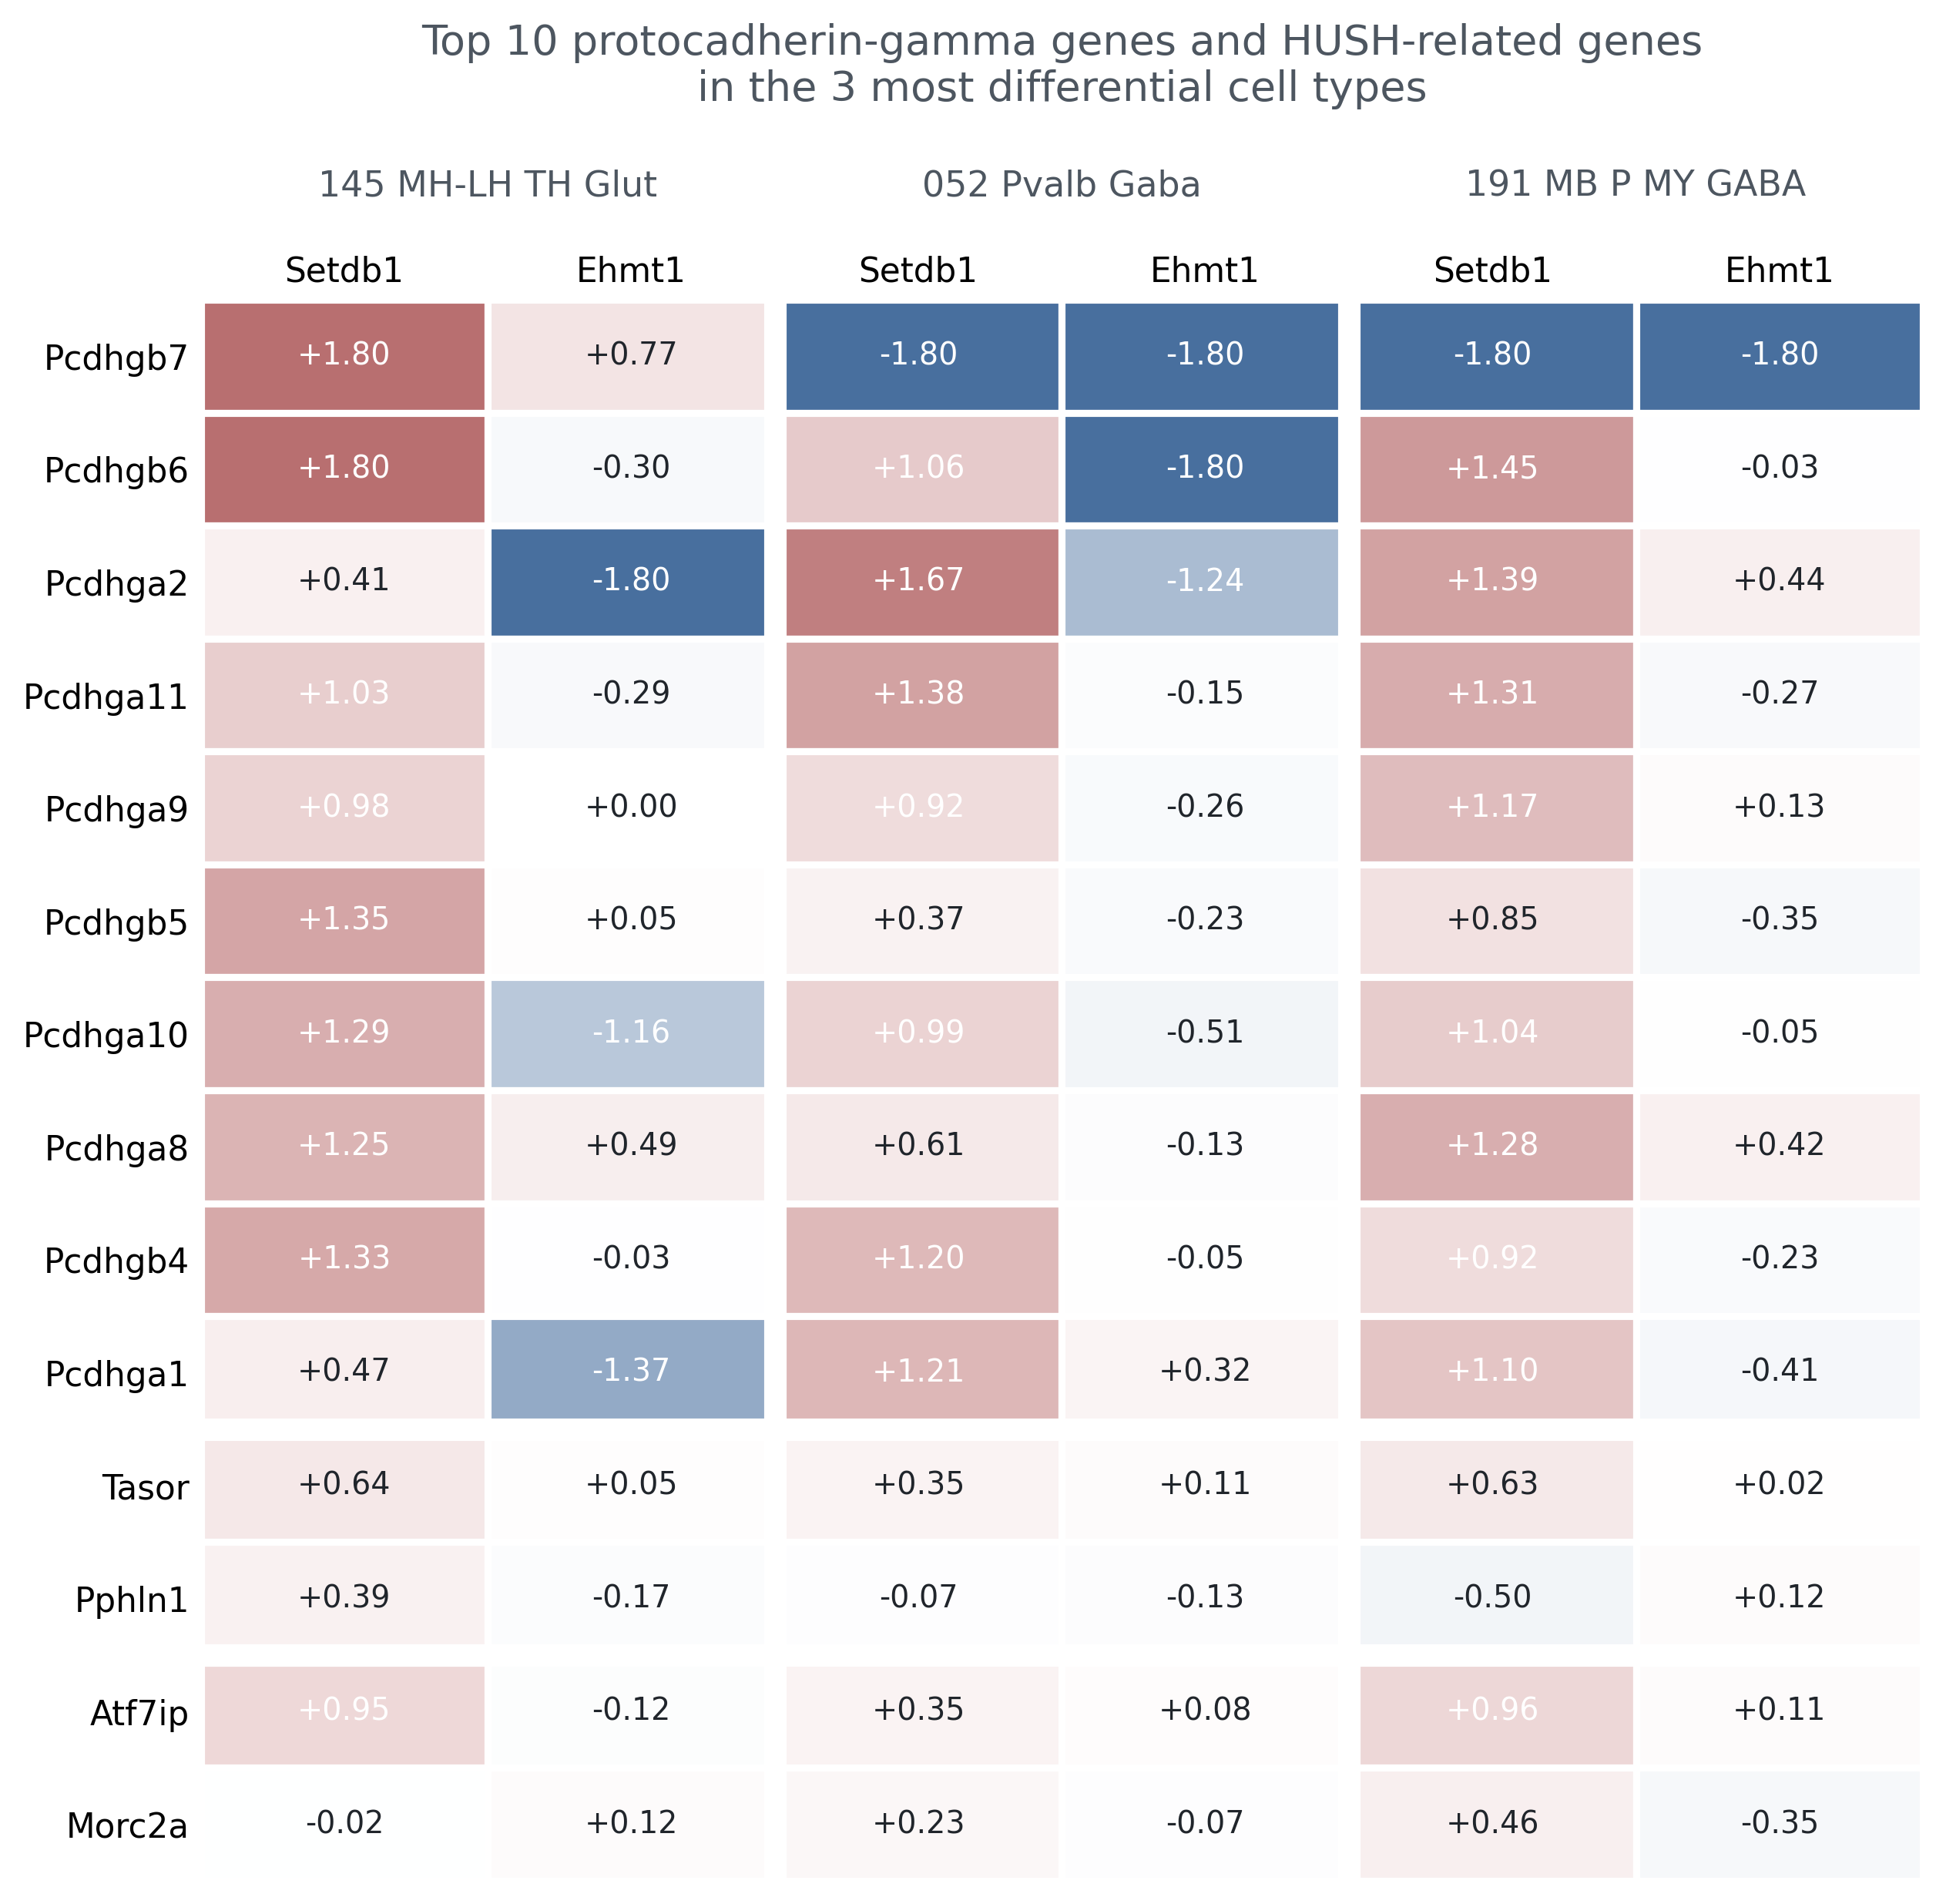

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Rectangle

matrix_path = ROOT / "src/manuscript_figures/fig4/g/setdb1_ehmt1/outputs/setdb1_ehmt1_focal_gene_logFC_matrix.csv"
source = pd.read_csv(matrix_path, index_col=0).astype(float).clip(-1.8, 1.8)
perturbations = ["Setdb1", "Ehmt1"]
hush_groups = {"TASOR-related": ["Tasor", "Pphln1"], "ATF7IP-related": ["Atf7ip", "Morc2a"]}
pcdhg_genes = [gene for gene in source.index if gene.startswith("Pcdhg")]
cell_types = [column.split(" | ", 1)[1] for column in source if column.startswith("Setdb1 |")]
paired_differences = pd.DataFrame({
    cell_type: (source.loc[pcdhg_genes, f"Setdb1 | {cell_type}"] -
                source.loc[pcdhg_genes, f"Ehmt1 | {cell_type}"]).abs()
    for cell_type in cell_types
})
gene_scores = paired_differences.mean(axis=1).sort_values(ascending=False)
top_genes = gene_scores.head(10).index.tolist()
plot_genes = top_genes + [gene for genes in hush_groups.values() for gene in genes]
top_cell_types = paired_differences.loc[top_genes].mean(axis=0).nlargest(3).index.tolist()
columns = [(cell_type, perturbation) for cell_type in top_cell_types for perturbation in perturbations]
plot_data = pd.DataFrame({
    f"{cell_type} | {perturbation}": source.loc[plot_genes, f"{perturbation} | {cell_type}"]
    for cell_type, perturbation in columns
}, index=plot_genes)

cmap = LinearSegmentedColormap.from_list("muted_diverging", ["#486f9e", "#e8edf3", "#ffffff", "#f1dfdf", "#b86f70"])
norm = TwoSlopeNorm(vmin=-1.8, vcenter=0, vmax=1.8)
fig, ax = plt.subplots(figsize=(9.2, 9.5))
for row in range(plot_data.shape[0]):
    for col in range(plot_data.shape[1]):
        value = plot_data.iat[row, col]
        ax.add_patch(Rectangle((col - .5, row - .5), 1, 1, facecolor=cmap(norm(value)), edgecolor="white", linewidth=2.2))
        ax.text(col, row, f"{value:+.2f}", ha="center", va="center", fontsize=9.5,
                color="white" if abs(value) >= .9 else "#20252b")
ax.set(xlim=(-.5, plot_data.shape[1] - .5), ylim=(plot_data.shape[0] - .5, -.5))
ax.set_yticks(np.arange(len(plot_genes)), labels=plot_genes)
ax.set_xticks(np.arange(len(columns)), labels=[p for _, p in columns])
ax.xaxis.tick_top(); ax.tick_params(axis="both", length=0, labelsize=10.5)
for group, cell_type in enumerate(top_cell_types):
    ax.text(group * 2 + .5, -1.35, cell_type, ha="center", va="bottom", fontsize=11, color="#4d5660", clip_on=False)
    if group: ax.axvline(group * 2 - .5, color="white", linewidth=7)
for boundary in (9.5, 11.5): ax.axhline(boundary, color="white", linewidth=7)
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_title("Top 10 protocadherin-gamma genes and HUSH-related genes\nin the 3 most differential cell types", fontsize=13, color="#4d5660", pad=62)
fig.subplots_adjust(left=.18, right=.99, bottom=.04, top=.76)
plt.show()

## Figure 4G — Atxn1/Cic target-level effect-vector similarity

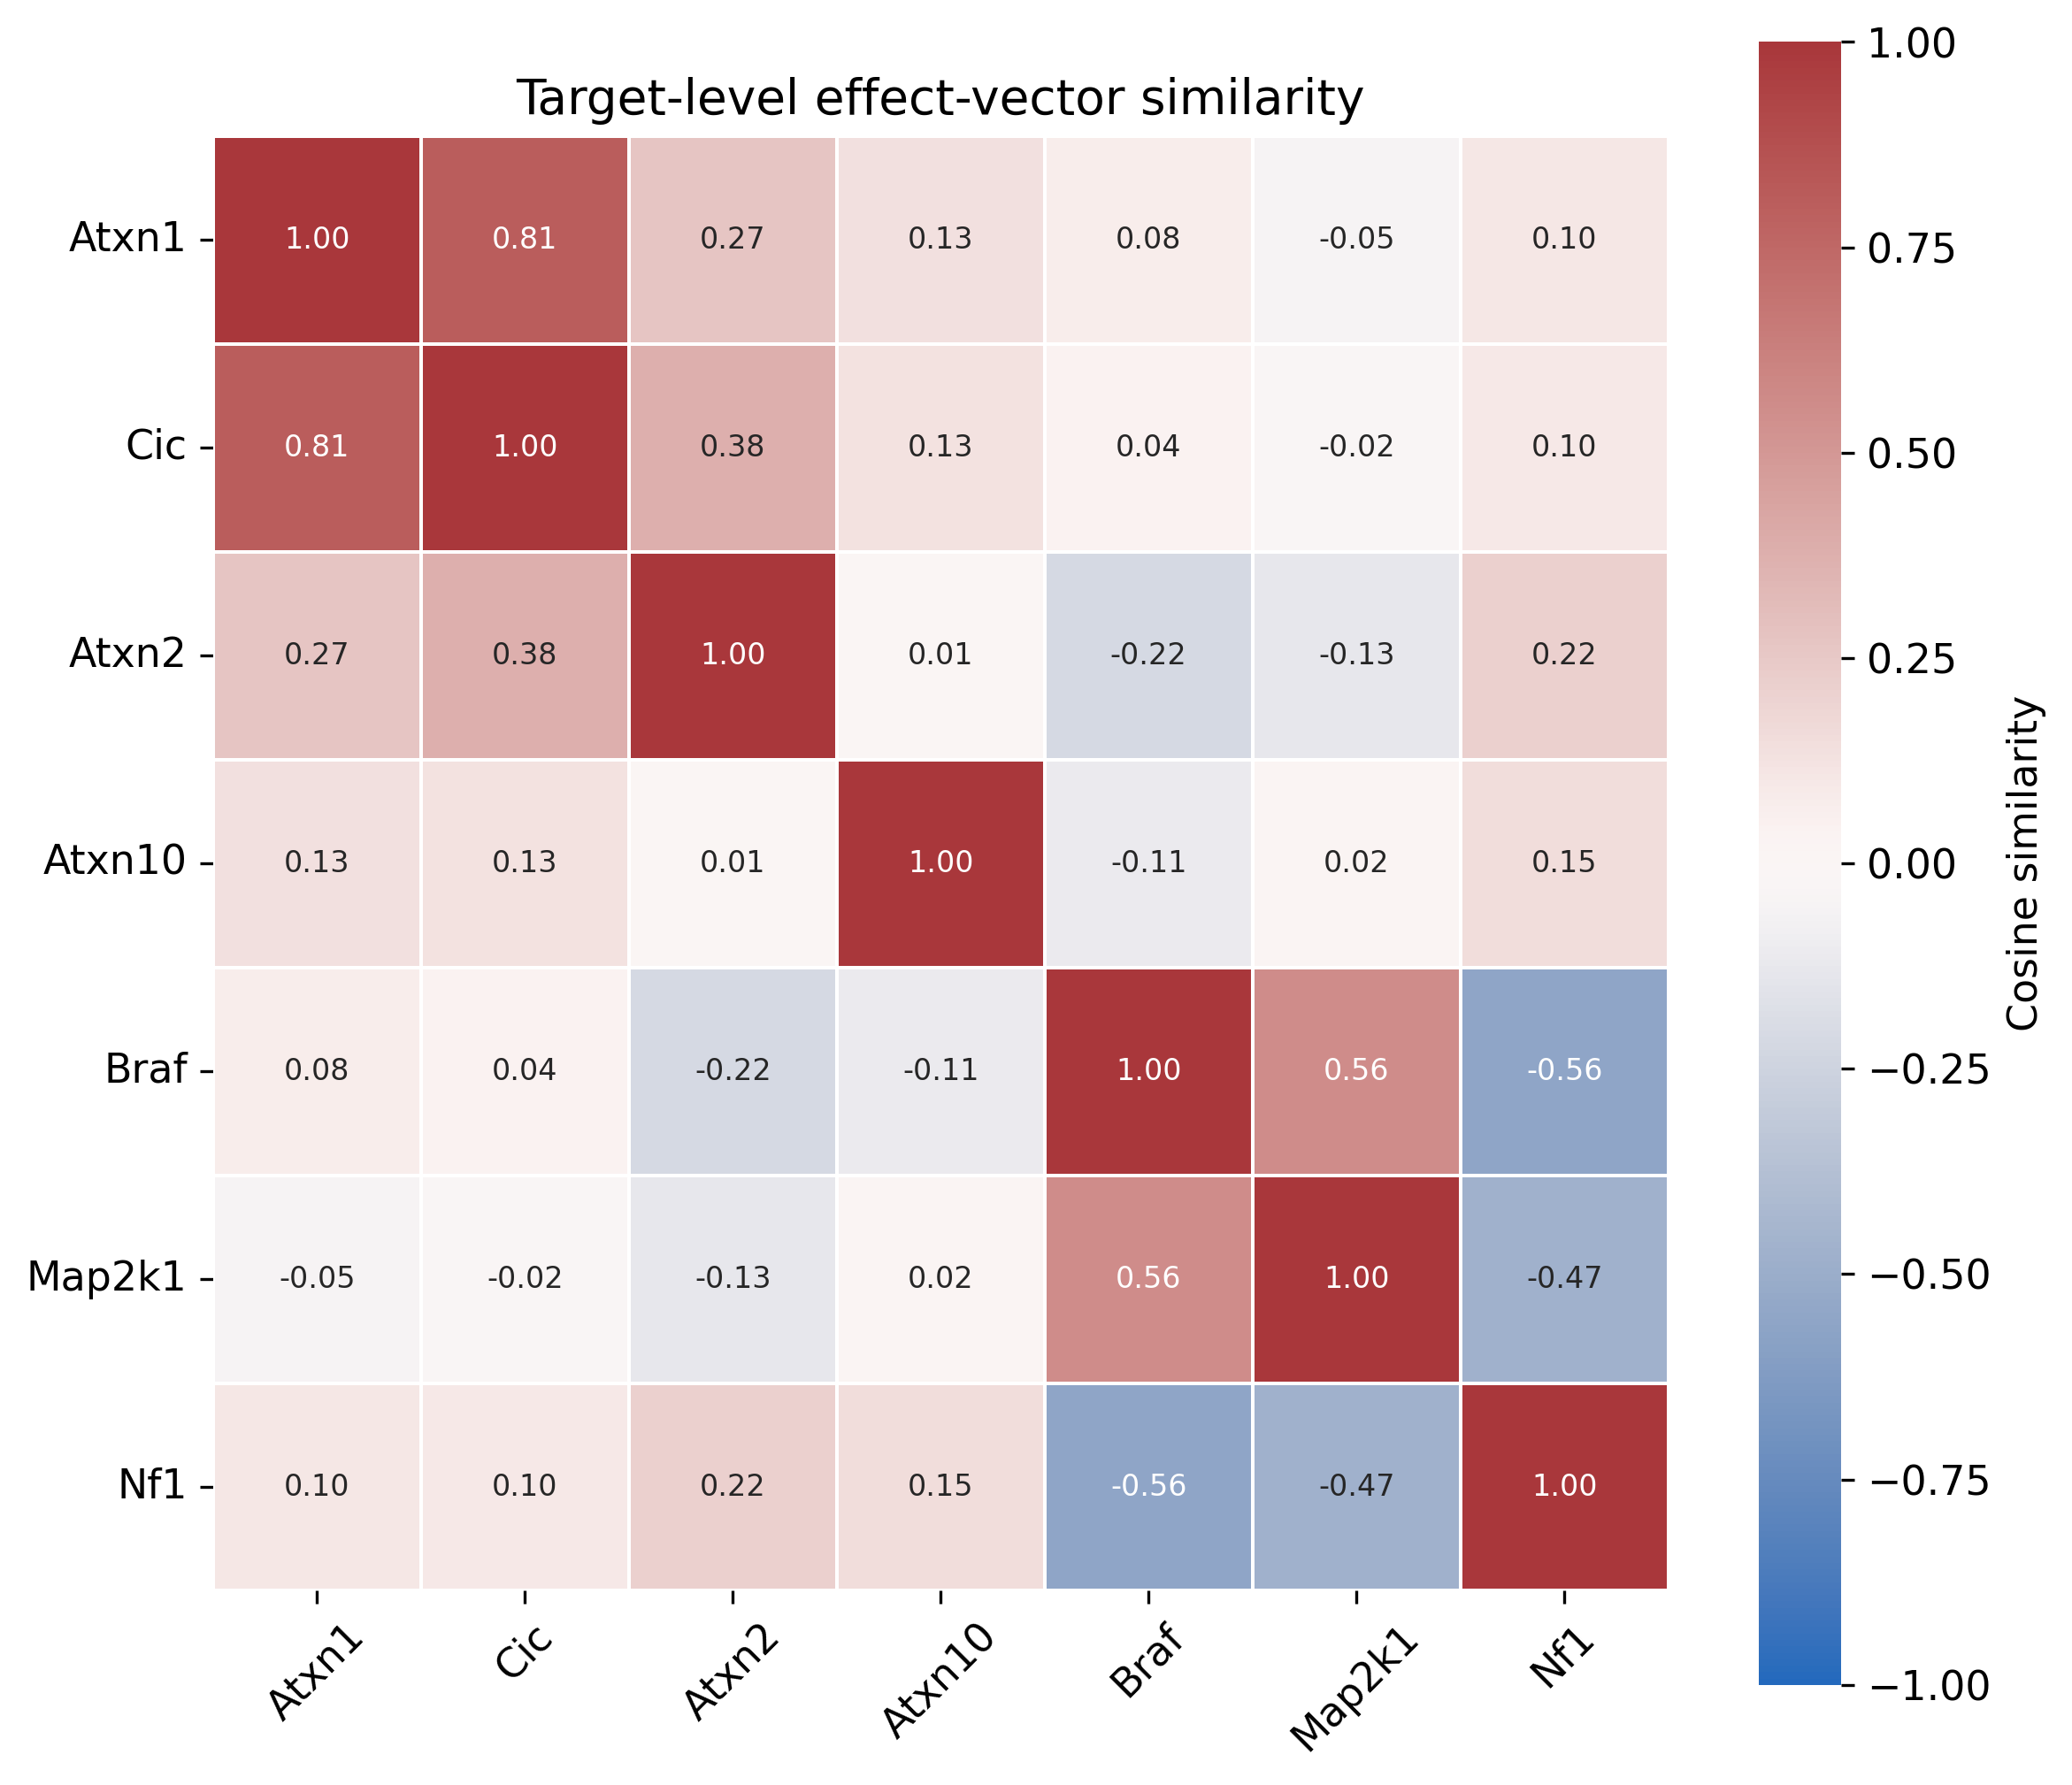

In [6]:
import seaborn as sns

effect_path = ROOT / "src/manuscript_figures/fig4/g/atxn1_cic/inputs/perturbation_effect_vectors_by_target.csv"
effect = pd.read_csv(effect_path, index_col="gene_target")
values = effect.to_numpy(float)
values = values / np.linalg.norm(values, axis=1, keepdims=True)
similarity = pd.DataFrame(values @ values.T, index=effect.index, columns=effect.index)
targets = ["Atxn1", "Cic", "Atxn2", "Atxn7", "Atxn10", "Braf", "Map2k1", "Nf1"]
available = [target for target in targets if target in similarity.index]
selected = similarity.loc[available, available]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(selected, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"fontsize": 8}, linewidths=.5,
            cbar_kws={"label": "Cosine similarity"}, ax=ax)
ax.set(title="Target-level effect-vector similarity", xlabel="", ylabel="")
ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.show()